# Playground
### where we will explore more complex Demographic Scenario with Custom Priors

In this notebook, we will discuss and try to design more realistic prior and model simulation for population scenarios. 

In reality, one population could go through multiple population size epochs with parameters that are difficult to detect (e.g., a random recombination rate). So we will define a prior that samples multiple effective population sizes `Ne_i` with a random recombination size. For each effective population size, we place them along pre-defined time windows. Then we simulate data to see how these choices affect the summaries (AFS).

## What we will do
- Define a BoxUniform prior over multiple effective population sizes (across epochs) and a recombination rate randomly sampled from a uniform distribution.
- You can edit epoch times and parameter ranges.
- Simulate tree sequences from sampled parameters.
- Visualize how `Ne` and `change times` shapes the AFS, which becomes our summary statistic for NPE.
- Try to think about how to design the prior and simulation for your own resesrch topic.

### Imports and setup
Load msprime, numpy, matplotlib, torch, and BoxUniform for the simulations.


In [1]:
import msprime
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.utils import BoxUniform

## Design a more realistic demographic prior
Edit these values to match your use case. 
### Choosing change_times
- Linear spacing (default) gives evenly spaced epochs.
- Exponential spacing (see option below, cf. doi:10.1111/1755-0998.13224) and log spacing cluster the change points nearer the present to resolve recent events more finely.

You can print out the different time intervals to look at the distribution. 

In [2]:
# Demography and sequencing settings
sequence_length = 1e6            # bp
mutation_rate = 1e-8             # per bp per generation
max_time = 5e4                 # maximum time for coalescent events

# Epoch configuration
num_epochs = 5

# Multiple ways to define change times
change_times = np.arange(0, max_time, max_time / num_epochs) 

""" we can also use other spacings for change times. Later in this notebook, we can compare the performance of different spacings.

# Exponential spacing of change times, uncomment to use
change_times =[(np.exp(np.log(1 + 0.1 * 50000) * i / 
                       (num_epochs - 1)) - 1) / 0.1
               for i in range(num_epochs)]

# Logarithmic spacing of change times, uncomment to use
change_times = np.hstack((0, np.logspace(2, np.log10(50000), num_epochs)))
"""

# Prior ranges (Ne and recombination)
ne_range = [100, 1e5]       
recomb_range = [1e-9, 1e-8]  


## Build the prior
We stack `num_epochs` population sizes (`Ne`) plus one recombination rate (`r`) into a single BoxUniform prior.

### Build the BoxUniform prior
Stack epoch-specific `Ne` values and a `recombination rate` into a single prior vector.


In [3]:
param_names = [f"Ne_epoch{i+1}" for i in range(num_epochs)] + ["recomb"]
low = torch.tensor([ne_range[0]] * num_epochs + [recomb_range[0]])
high = torch.tensor([ne_range[1]] * num_epochs + [recomb_range[1]])

prior = BoxUniform(low=low, high=high)

## Simulator
Takes a parameter draw `theta` (`Ne` + `r`), builds the demography with size changes at `change_times`, runs ancestry and mutation simulation, and returns the folded AFS.

### Simulator functions
Simulate demography with epoch-specific Ne and recombination, returning folded AFS and tree sequences.


In [4]:
def simulator(theta, sequence_length, mutation_rate, change_times):
    s_stats = []
    TSs = []
    for pop in theta.tolist():
        ts = simulate_population(pop, 
                                 sequence_length=sequence_length, 
                                 samples=10, 
                                 mutation_rate=mutation_rate, 
                                 change_times=change_times)
        s = ts.allele_frequency_spectrum(polarised=False) # returns folded AFS. Set polarised=True to use unfolded AFS
        s_stats.append(s)
        TSs.append(ts)
    return torch.tensor(s_stats, dtype=torch.float32), TSs

def simulate_population(pop, sequence_length, samples, mutation_rate, change_times):
    Ne = pop[:-1]
    r = pop[-1]
    # Define demography
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne[0])
    
    for t, ne in zip(change_times[1:], Ne[1:]):
        demography.add_population_parameters_change(time=t, initial_size=ne)

    # Simulate ancestry and mutations
    ts_anc = msprime.sim_ancestry(samples=samples,
                                recombination_rate=r,
                                sequence_length=sequence_length,
                                demography=demography, random_seed=42)
    ts = msprime.sim_mutations(ts_anc, rate=mutation_rate, random_seed=42)

    return ts

## Inspect one draw
Sample parameters, run a simulation, and look at the folded AFS counts.

### Sample one draw and simulate
Draw parameters from the prior and run the simulator once.


In [5]:
theta_sample = prior.sample((1,))
afs, ts = simulator(theta_sample, sequence_length, mutation_rate, change_times)

/var/folders/k5/fxhm2ffn0vz3vy1__6s7lhn80000gp/T/ipykernel_60331/1859847105.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1741997254679/work/torch/csrc/utils/tensor_new.cpp:281.)
  return torch.tensor(s_stats, dtype=torch.float32), TSs


### Inspect the first TreeSequence object


In [6]:
ts[0]

### Report tree and site counts


In [7]:
print("Trees:", ts[0].num_trees, "sites:", ts[0].num_sites)

Trees: 3341 sites: 4519


### Plot folded AFS for the sampled demography


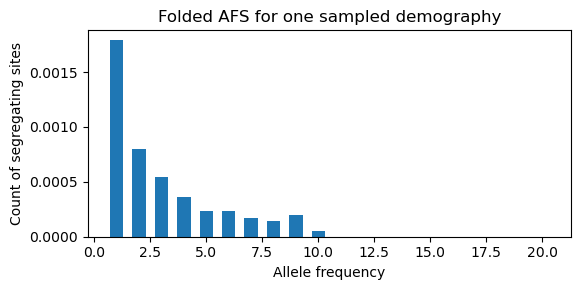

In [8]:
freqs = np.arange(1, len(afs.squeeze()))
plt.figure(figsize=(6, 3))
plt.bar(freqs, afs.squeeze()[1:], width=0.6)
plt.xlabel('Allele frequency')
plt.ylabel('Count of segregating sites')
plt.title('Folded AFS for one sampled demography')
plt.tight_layout()
plt.show()

## Six demographic scenarios and their AFS
Below we compare `21` hand-crafted `Ne` trajectories under different scenarios(`Medium, Large, Decline, Expansion, Bottleneck, Zigzag`) (cf. doi:10.1111/1755-0998.13224) with a fixed recombination rate `1e-8`. 

Each trajectory is a sequence of population sizes across time windows. We simulate each scenario and plot its **normalized folded AFS** (counts divided by total segregating sites) to show how demographic history reshapes the allele frequency distribution in a single view.

### Define six demographic trajectories
Log10 Ne profiles for Medium, Large, Decline, Expansion, Bottleneck, Zigzag; convert to Ne.


In [9]:
# Population sizes are defined on a log10 scale

# Reminder: times are reversed in msprime, so time 0 is present and time max_time is the past!

scenarios = {'Medium': [3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7],   
             'Large': 4.7 * np.ones(shape=21, dtype='float'), 
             'Decline': [2.5, 2.5, 3, 3, 3, 3, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6], 
             'Expansion': [4.7, 4.7, 4.7, 4.6, 4.6, 4.5, 4.4, 4.3, 4, 3.7, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4], 
             'Bottleneck': [4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.5, 4.15, 3.8, 4.3, 4.8, 4.55, 4.3, 4.05, 3.8, 3.8, 3.8, 3.8], 
             'Zigzag': [4.8, 4.8, 4.8, 4.5, 4.15, 3.8, 4.15, 4.5, 4.8, 4.5, 4.15, 3.8, 4.3, 4.8, 4.55, 4.3, 4.05, 3.8, 3.8, 3.8, 3.8]}
scenarios = {k:10**np.array(scenarios[k]) for k in scenarios.keys()}

### Plot normalized folded AFS (linear change times)
Compare scenarios with evenly spaced change times; AFS normalized by total segregating sites.


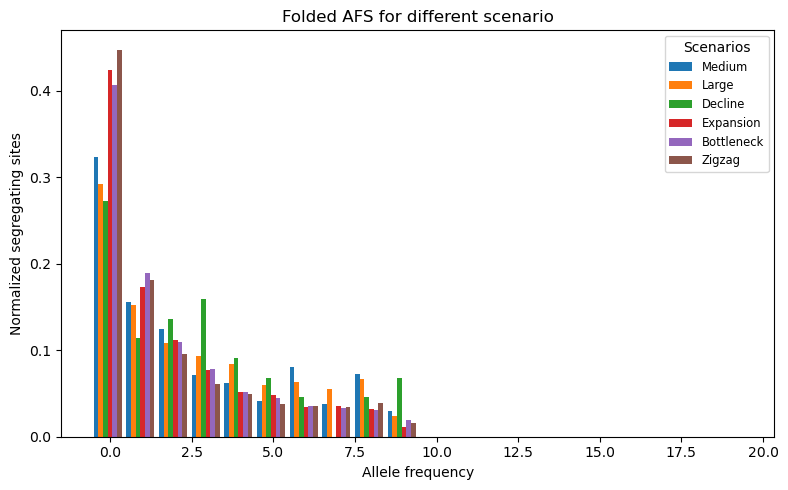

In [10]:
plt.figure(figsize=(8, 5))

for idx, sce in enumerate(scenarios):
    Ne_sce = scenarios[sce]
    pop_params = list(Ne_sce) + [1e-8]
    afs_sce, ts_sce = simulator(torch.tensor([pop_params], dtype=torch.float32), 
                               sequence_length, mutation_rate, np.arange(0, 130000, 130000 / 21) )
    freqs = np.arange(1, len(afs_sce.squeeze()))

    bar_width = 3 / len(Ne_sce)
    offset = (idx - (len(Ne_sce)-1)/2) * bar_width
    afs_sce /= afs_sce.sum()  # Normalize AFS
    plt.bar(freqs + offset, afs_sce.squeeze()[1:], width=bar_width, label=f'{sce}')

plt.xlabel('Allele frequency')
plt.ylabel('Normalized segregating sites')
plt.title(f'Folded AFS for different scenario')
plt.legend(title='Scenarios', fontsize='small', loc='upper right')
plt.tight_layout()
plt.show() 

### Plot normalized folded AFS (log-spaced change times)
Compare scenarios with log-spaced change times; AFS normalized.


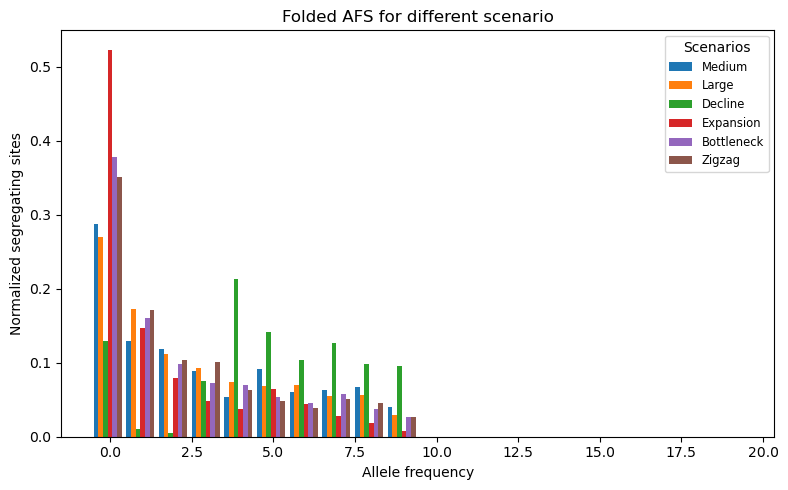

In [11]:
plt.figure(figsize=(8, 5))
for idx, sce in enumerate(scenarios):
    Ne_sce = scenarios[sce]
    pop_params = list(Ne_sce) + [1e-8]
    afs_sce, ts_sce = simulator(torch.tensor([pop_params], dtype=torch.float32), 
                               sequence_length, mutation_rate, np.hstack((0, np.logspace(2, np.log10(130000), 21))))
    freqs = np.arange(1, len(afs_sce.squeeze()))

    bar_width = 3 / len(Ne_sce)
    offset = (idx - (len(Ne_sce)-1)/2) * bar_width
    afs_sce /= afs_sce.sum()  # Normalize AFS
    plt.bar(freqs + offset, afs_sce.squeeze()[1:], width=bar_width, label=f'{sce}')

plt.xlabel('Allele frequency')
plt.ylabel('Normalized segregating sites')
plt.title(f'Folded AFS for different scenario')
plt.legend(title='Scenarios', fontsize='small', loc='upper right')
plt.tight_layout()
plt.show() 

### Plot normalized folded AFS (exponential change times)
Compare scenarios with exponentially spaced change times; AFS normalized.


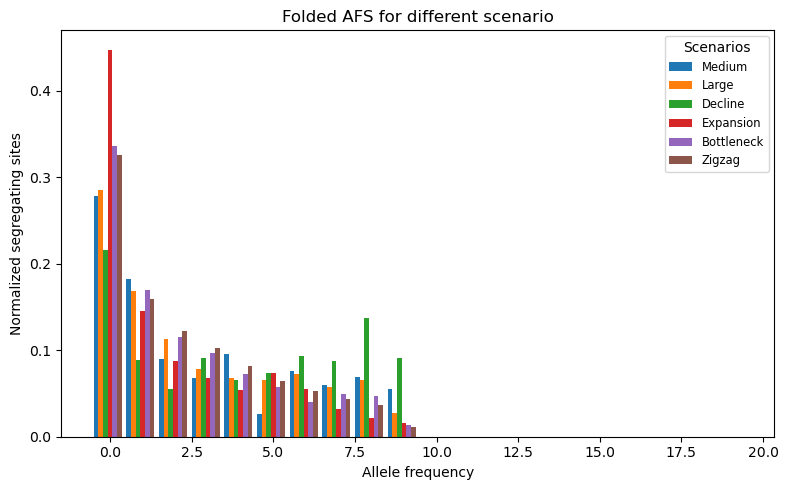

In [12]:
plt.figure(figsize=(8, 5))
for idx, sce in enumerate(scenarios):
    Ne_sce = scenarios[sce]
    pop_params = list(Ne_sce) + [1e-8]
    afs_sce, ts_sce = simulator(torch.tensor([pop_params], dtype=torch.float32), 
                               sequence_length, mutation_rate, [(np.exp(np.log(1 + 0.1 * 130000) * i / (21 - 1)) - 1) / 0.1 for i in range(21)])
    freqs = np.arange(1, len(afs_sce.squeeze()))

    bar_width = 3 / len(Ne_sce)
    offset = (idx - (len(Ne_sce)-1)/2) * bar_width
    afs_sce /= afs_sce.sum()  # Normalize AFS
    plt.bar(freqs + offset, afs_sce.squeeze()[1:], width=bar_width, label=f'{sce}')

plt.xlabel('Allele frequency')
plt.ylabel('Normalized segregating sites')
plt.title(f'Folded AFS for different scenario')
plt.legend(title='Scenarios', fontsize='small', loc='upper right')
plt.tight_layout()
plt.show() 

## Why your prior matters
A good prior is not just a formal requirement, it shapes every simulation you pass to NPE. 

We need to consider how to:
- Cover the plausible space: set `Ne` and `recombination` ranges wide enough to include what you truly expect, but not too wide that most simulations are unrealistic noise.
- Resolve time scales: choose change time grids (`linear/log/exponential` and so on) that give better resolution where you care about recent vs. ancient events.
- Match the biological scenario: set `mutation/recombination` ranges and Ne magnitudes that reflect your system (e.g., human vs. microbial vs. plant).
- Balance breadth and density: if the prior is too broad, NPE spends capacity on unlikely regions. If the prior is too narrow, you would likely miss the truth.

When your prior is thoughtfully designed, the simulated AFS summaries become far more informative, and NPE learns a sharper, better-calibrated posterior.

#### What if we use a random recombination rate in this example instead of a fixed one? Try to configure it yourself and play around.